# Análise Econométrica: Estado vs Crescimento

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams["figure.figsize"] = (8,5)

## Carregar dados

In [38]:
df = pd.read_csv("dataset_econometria.csv")
df.head()

,country,year,gdp_growth,gov_size,investment,inflation,trade_open,gdp_future,gov_lag1,gov_lag2
0,BRA,1992,-0.544072,17.063016,18.423259,951.962053,19.253375,4.924690,17.899844,19.290922
1,BRA,1993,4.924690,17.664023,19.283116,1927.380790,19.599321,5.852870,17.063016,17.899844
2,BRA,1994,5.852870,17.865717,20.748085,2075.888398,18.674760,4.223794,17.664023,17.063016
3,BRA,1995,4.223794,20.927925,20.286298,66.007034,16.984460,2.208864,17.865717,17.664023
4,BRA,1996,2.208864,19.750827,18.640654,15.757666,15.635591,3.394846,20.927925,17.865717


## Estrutura

In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     125 non-null    str    
 1   year        125 non-null    int64  
 2   gdp_growth  125 non-null    float64
 3   gov_size    125 non-null    float64
 4   investment  125 non-null    float64
 5   inflation   125 non-null    float64
 6   trade_open  125 non-null    float64
 7   gdp_future  125 non-null    float64
 8   gov_lag1    125 non-null    float64
 9   gov_lag2    125 non-null    float64
dtypes: float64(8), int64(1), str(1)
memory usage: 9.9 KB


## Ajustes de inflação

In [40]:
# log da inflação para estabilizar escala
df["inflation_log"] = np.log1p(df["inflation"])

# remover hiperinflação extrema
df = df[df["inflation"] < 500]

df.describe()

,year,gdp_growth,gov_size,investment,inflation,trade_open,gdp_future,gov_lag1,gov_lag2,inflation_log
count,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000,122.000000
mean,2007.483607,2.624602,16.459372,21.181833,4.401162,45.529616,2.513491,16.395851,16.333615,1.434764
std,8.901884,2.807733,3.164672,2.794023,6.439164,21.268031,2.700921,3.187819,3.210482,0.644210
min,1992.000000,-6.143475,9.551400,14.558987,-0.355546,15.635591,-6.143475,9.551400,9.551400,-0.439352
25%,2000.000000,1.246301,14.201988,19.404599,1.712663,25.675404,1.176760,14.123908,14.049078,0.997922
50%,2007.500000,2.640643,16.746770,21.166901,3.037155,41.850946,2.590341,16.746770,16.746770,1.395538
75%,2015.000000,4.019274,19.175453,22.870579,5.001054,65.076818,3.971314,19.148430,19.120363,1.791875
max,2023.000000,11.501931,21.724394,28.634840,66.007034,88.785754,11.314920,21.724394,21.724394,4.204798


## Checagem de lags

In [41]:
df = df.sort_values(["country","year"])

df["gdp_future"] = df.groupby("country")["gdp_growth"].shift(-1)

df = df.dropna()

## Visual inicial

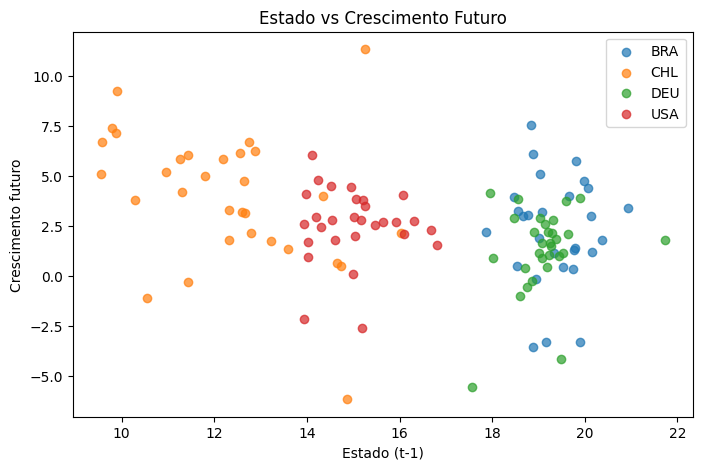

In [42]:
plt.figure()

for country in df["country"].unique():
    subset = df[df["country"] == country]
    plt.scatter(subset["gov_lag1"], subset["gdp_future"], label=country, alpha=0.7)

plt.xlabel("Estado (t-1)")
plt.ylabel("Crescimento futuro")
plt.title("Estado vs Crescimento Futuro")
plt.legend()

plt.show()

## Regressão simples

In [43]:
model_simple = smf.ols(
    "gdp_future ~ gov_lag1",
    data=df
).fit(cov_type='HC1')

print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_future   R-squared:                       0.127
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     17.65
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           5.24e-05
Time:                        18:00:06   Log-Likelihood:                -277.33
No. Observations:                 118   AIC:                             558.7
Df Residuals:                     116   BIC:                             564.2
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.5076      1.228      6.113      0.0

## Regressão com controles

In [44]:
model_controls = smf.ols(
    "gdp_future ~ gov_lag1 + investment + inflation_log + trade_open",
    data=df
).fit(cov_type='HC1')

print(model_controls.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_future   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     8.415
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           5.59e-06
Time:                        18:00:06   Log-Likelihood:                -275.10
No. Observations:                 118   AIC:                             560.2
Df Residuals:                     113   BIC:                             574.0
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        14.9060      3.066      4.861

## Modelo com efeitos fixos (país + tempo)

In [45]:
model_fe = smf.ols(
    "gdp_future ~ gov_lag1 + investment + inflation_log + trade_open + C(country) + C(year)",
    data=df
).fit(cov_type='HC1')

print(model_fe.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_future   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     8.460
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.17e-15
Time:                        18:00:06   Log-Likelihood:                -206.69
No. Observations:                 118   AIC:                             489.4
Df Residuals:                      80   BIC:                             594.7
Df Model:                          37                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            17.0745      5.30

## Modelo com múltiplos lags

In [46]:
model_lags = smf.ols(
    "gdp_future ~ gov_lag1 + gov_lag2 + investment + inflation_log + trade_open + C(country) + C(year)",
    data=df
).fit(cov_type='HC1')

print(model_lags.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_future   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.611
Method:                 Least Squares   F-statistic:                     8.305
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           1.93e-15
Time:                        18:00:06   Log-Likelihood:                -206.39
No. Observations:                 118   AIC:                             490.8
Df Residuals:                      79   BIC:                             598.8
Df Model:                          38                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            18.3260      6.36

## Tendência visual

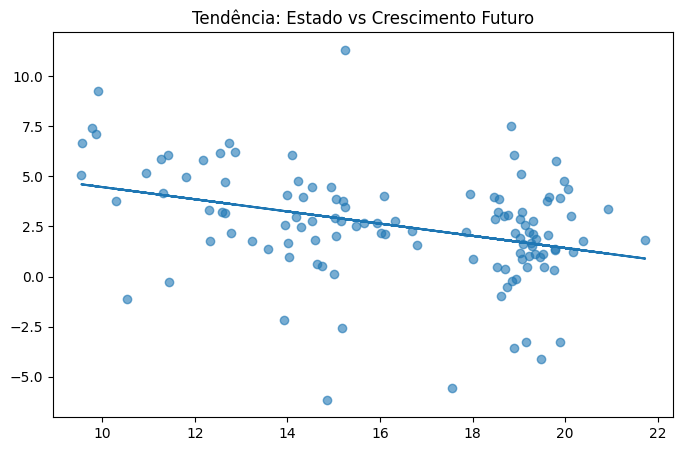

In [47]:
z = np.polyfit(df["gov_lag1"], df["gdp_future"], 1)
p = np.poly1d(z)

plt.figure()
plt.scatter(df["gov_lag1"], df["gdp_future"], alpha=0.6)
plt.plot(df["gov_lag1"], p(df["gov_lag1"]))

plt.title("Tendência: Estado vs Crescimento Futuro")
plt.show()

## Multicolinearidade (VIF)

In [48]:
X = df[["gov_lag1", "investment", "inflation_log", "trade_open"]]

vif = pd.DataFrame()
vif["var"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

             var        VIF
0       gov_lag1  12.074079
1     investment  23.445579
2  inflation_log   6.320384
3     trade_open   7.232248


## VISUALS

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns

# ── Tema dark dramático para vídeo ──────────────────────────────────────────
DARK_BG   = "#0a0a0f"
PANEL_BG  = "#12121a"
GREEN     = "#4fffb0"
RED       = "#ff4d6d"
BLUE      = "#7b88ff"
YELLOW    = "#ffd166"
GRAY      = "#444455"
TEXT_CLR  = "#f0eee8"
MUTED     = "#555566"

plt.rcParams.update({
    "figure.facecolor"  : DARK_BG,
    "axes.facecolor"    : PANEL_BG,
    "axes.edgecolor"    : GRAY,
    "axes.labelcolor"   : TEXT_CLR,
    "axes.titlecolor"   : TEXT_CLR,
    "axes.titlesize"    : 18,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 12,
    "xtick.color"       : MUTED,
    "ytick.color"       : MUTED,
    "text.color"        : TEXT_CLR,
    "grid.color"        : "#1e1e2e",
    "grid.linewidth"    : 0.8,
    "figure.figsize"    : (9, 5),
    "figure.dpi"        : 130,
    "font.family"       : "DejaVu Sans",
    "legend.facecolor"  : PANEL_BG,
    "legend.edgecolor"  : GRAY,
})

COUNTRY_COLORS = {"BRA": GREEN, "CHL": RED, "DEU": BLUE, "USA": YELLOW}

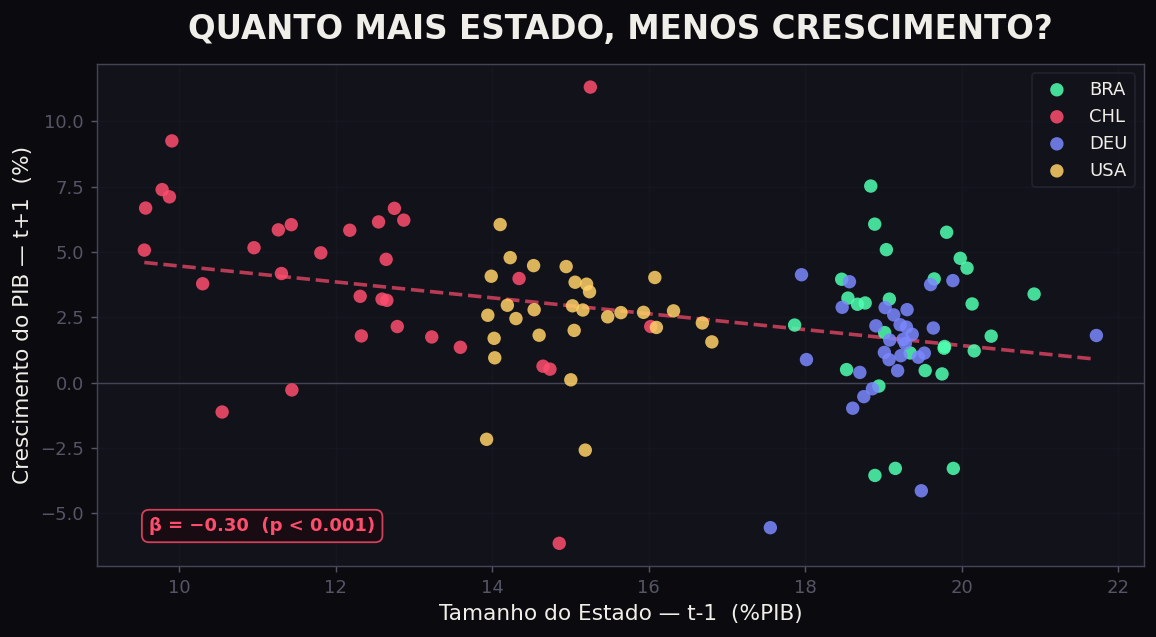

In [50]:
fig, ax = plt.subplots()
fig.patch.set_facecolor(DARK_BG)

for country, grp in df.groupby("country"):
    ax.scatter(grp["gov_lag1"], grp["gdp_future"],
               color=COUNTRY_COLORS[country], s=55, alpha=0.85,
               edgecolors="none", label=country, zorder=3)

# linha de tendência geral
z = np.polyfit(df["gov_lag1"], df["gdp_future"], 1)
x_line = np.linspace(df["gov_lag1"].min(), df["gov_lag1"].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color=RED, lw=2,
        linestyle="--", alpha=0.7, zorder=2)

ax.set_title("QUANTO MAIS ESTADO, MENOS CRESCIMENTO?", pad=14)
ax.set_xlabel("Tamanho do Estado — t-1  (%PIB)")
ax.set_ylabel("Crescimento do PIB — t+1  (%)")
ax.grid(True, axis="both", alpha=0.4)
ax.axhline(0, color=GRAY, lw=0.8)
ax.legend(framealpha=0.3, fontsize=10)

# anotação do coeficiente
ax.annotate("β = −0.30  (p < 0.001)", xy=(0.05, 0.07),
            xycoords="axes fraction", fontsize=10,
            color=RED, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#1a0a0f",
                      edgecolor=RED, alpha=0.8))
plt.tight_layout()
plt.show()

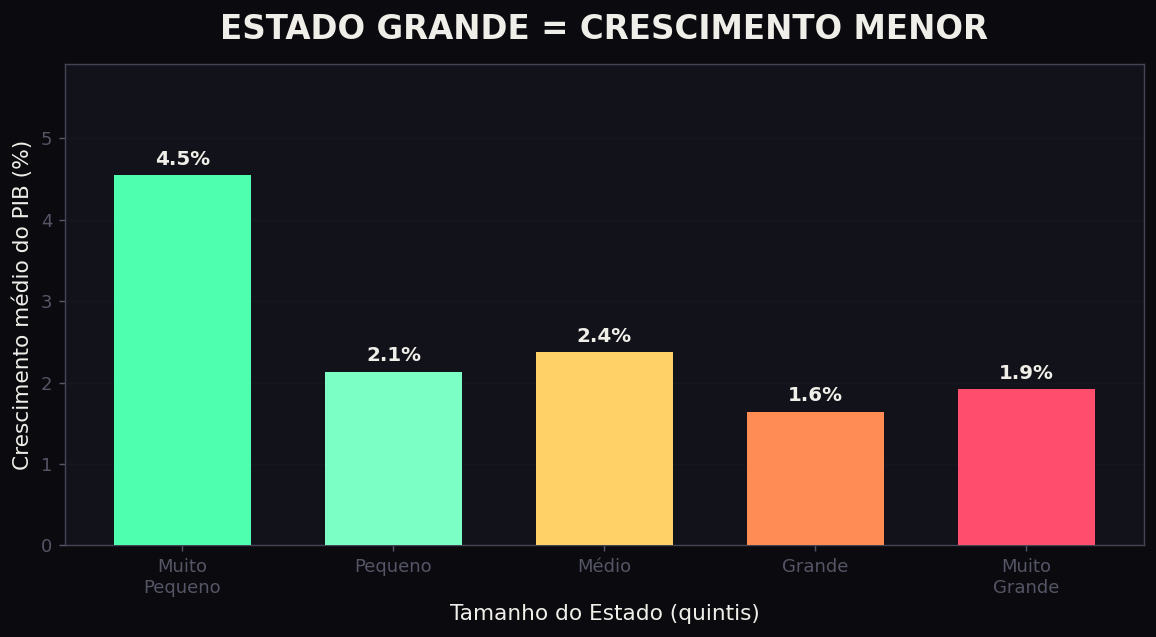

In [51]:
df["gov_bin"] = pd.qcut(df["gov_lag1"], 5,
    labels=["Muito\nPequeno","Pequeno","Médio","Grande","Muito\nGrande"])
grouped = df.groupby("gov_bin", observed=True)["gdp_future"].mean()

palette = [GREEN, "#7bffc5", YELLOW, "#ff8c55", RED]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(grouped.index, grouped.values,
              color=palette, width=0.65, edgecolor="none", zorder=3)

for bar, val in zip(bars, grouped.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.08,
            f"{val:.1f}%", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=TEXT_CLR)

ax.set_title("ESTADO GRANDE = CRESCIMENTO MENOR", pad=14)
ax.set_ylabel("Crescimento médio do PIB (%)")
ax.set_xlabel("Tamanho do Estado (quintis)")
ax.grid(axis="y", alpha=0.4)
ax.set_ylim(0, grouped.max() * 1.3)
plt.tight_layout()
plt.show()

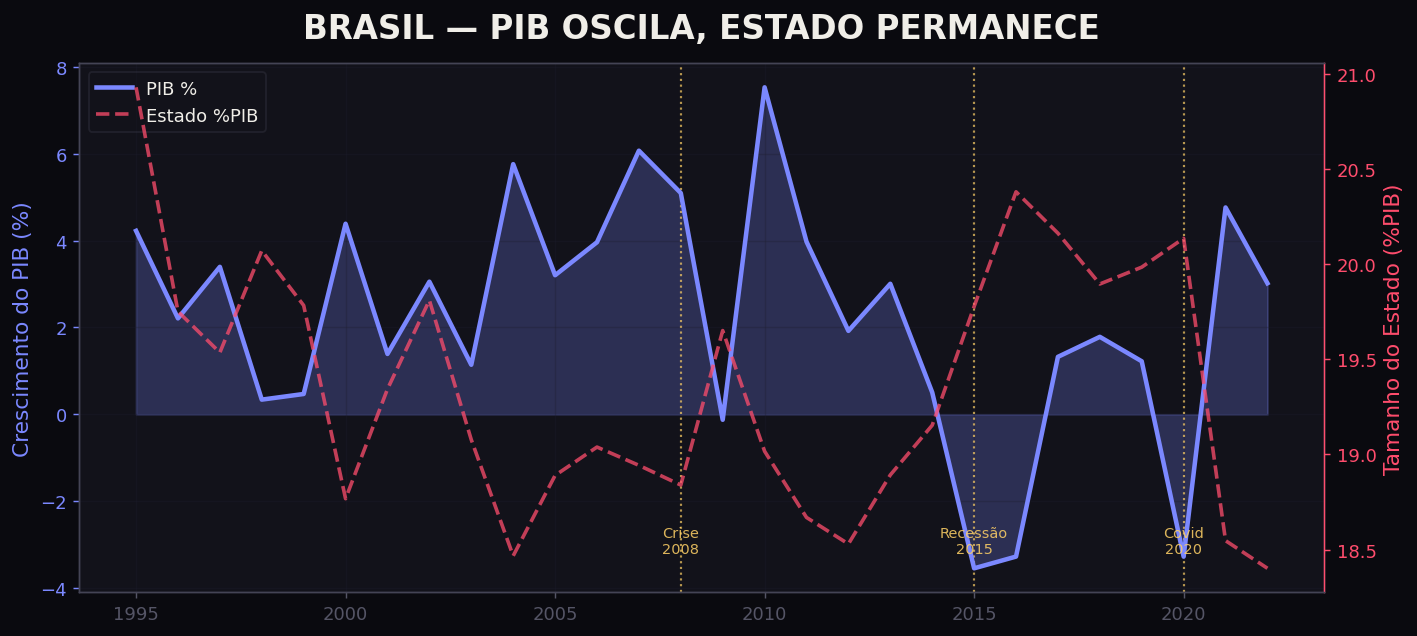

In [52]:
df_bra = df[df["country"] == "BRA"].copy()
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.fill_between(df_bra["year"], df_bra["gdp_growth"],
                 alpha=0.25, color=BLUE)
ax1.plot(df_bra["year"], df_bra["gdp_growth"],
         color=BLUE, lw=2.5, label="PIB %", zorder=3)

ax2.plot(df_bra["year"], df_bra["gov_size"],
         color=RED, lw=2, linestyle="--",
         alpha=0.75, label="Estado %PIB")

for ano, rotulo, dy in [(2008,"Crise\n2008",-3.2),
                         (2015,"Recessão\n2015",-3.2),
                         (2020,"Covid\n2020",-3.2)]:
    ax1.axvline(ano, color=YELLOW, lw=1.2, linestyle=":", alpha=0.7)
    ax1.annotate(rotulo, xy=(ano, dy), fontsize=8,
                 color=YELLOW, ha="center", alpha=0.85)

ax1.set_title("BRASIL — PIB OSCILA, ESTADO PERMANECE", pad=14)
ax1.set_ylabel("Crescimento do PIB (%)", color=BLUE)
ax2.set_ylabel("Tamanho do Estado (%PIB)", color=RED)
ax1.tick_params(axis="y", colors=BLUE)
ax2.tick_params(axis="y", colors=RED)
ax2.spines["right"].set_edgecolor(RED)
ax1.grid(axis="both", alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=10, framealpha=0.3)
plt.tight_layout()
plt.show()

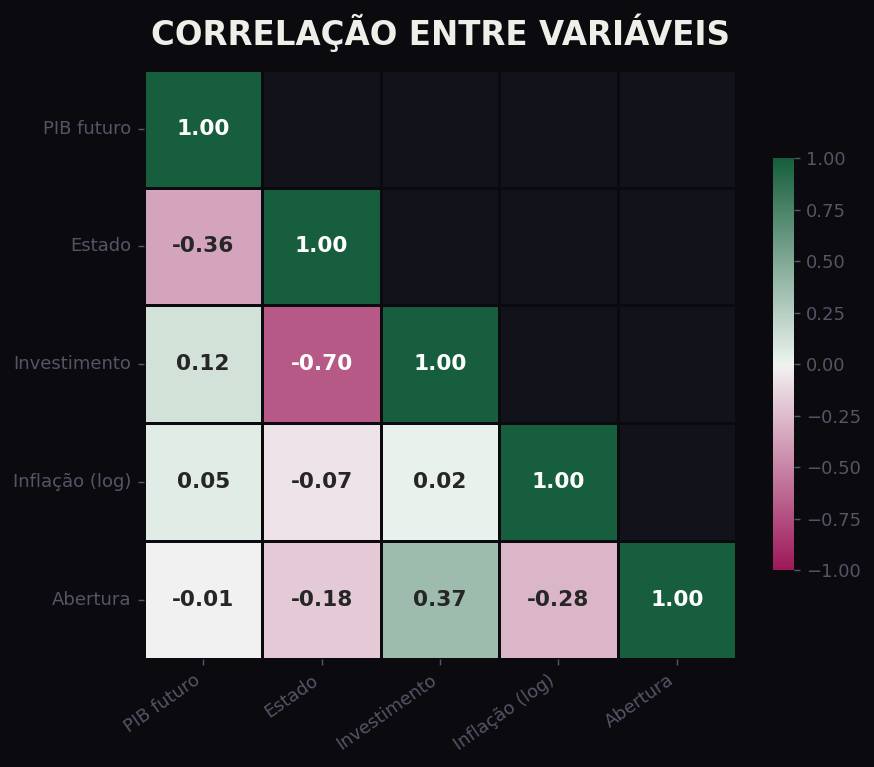

In [55]:
corr_vars = ["gdp_future","gov_lag1","investment","inflation_log","trade_open"]
labels_pt  = ["PIB futuro","Estado","Investimento","Inflação (log)","Abertura"]
corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(7, 6))

# máscara triangular superior
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(350, 145, s=90, l=35, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap=cmap, center=0, vmin=-1, vmax=1,
            linewidths=1.5, linecolor=DARK_BG,
            annot_kws={"size":12,"weight":"bold"},
            ax=ax, cbar_kws={"shrink":0.7})

ax.set_xticklabels(labels_pt, rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(labels_pt, rotation=0, fontsize=10)
ax.set_title("CORRELAÇÃO ENTRE VARIÁVEIS", pad=14)
ax.collections[0].colorbar.ax.yaxis.set_tick_params(color=MUTED)
plt.tight_layout()
plt.show()

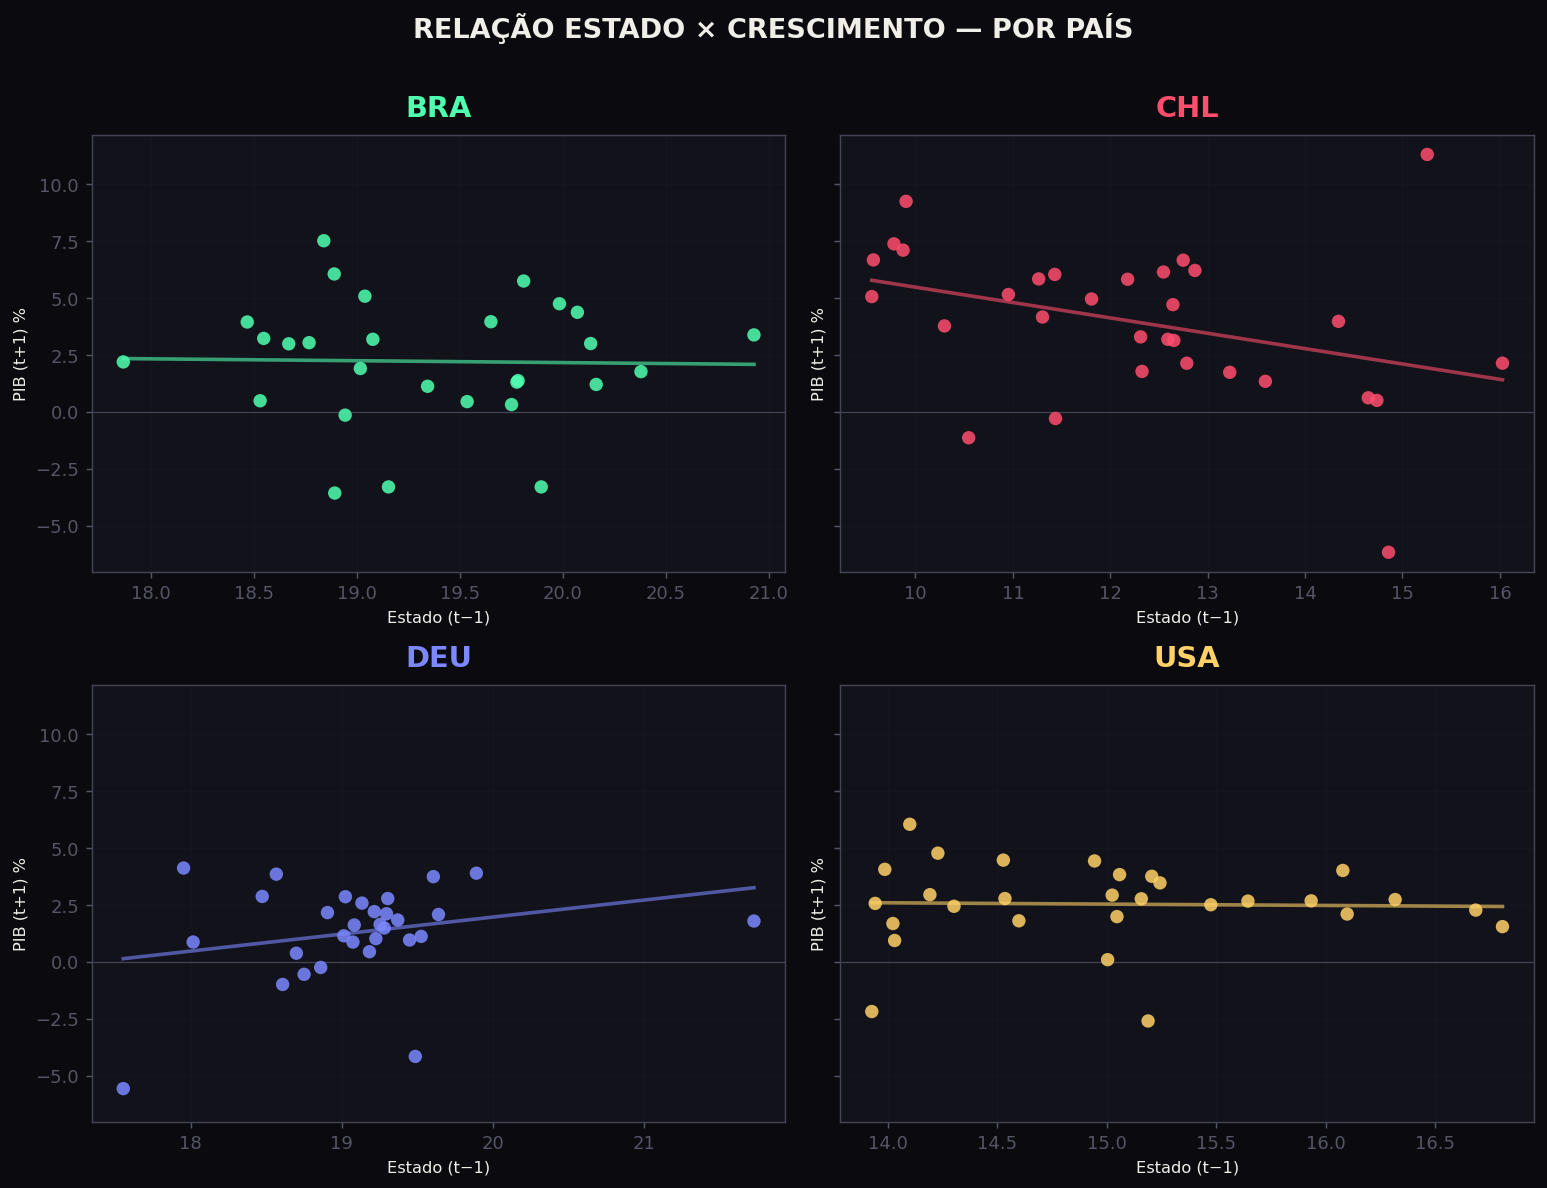

In [56]:
countries = df["country"].unique()
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True, sharex=False)
fig.patch.set_facecolor(DARK_BG)
axes_flat = axes.flatten()

for ax, country in zip(axes_flat, countries):
    grp = df[df["country"] == country]
    color = COUNTRY_COLORS[country]
    ax.scatter(grp["gov_lag1"], grp["gdp_future"],
               color=color, s=55, alpha=0.85, edgecolors="none", zorder=3)
    z = np.polyfit(grp["gov_lag1"], grp["gdp_future"], 1)
    x_l = np.linspace(grp["gov_lag1"].min(), grp["gov_lag1"].max(), 80)
    ax.plot(x_l, np.poly1d(z)(x_l), color=color, lw=2, alpha=0.6)
    ax.set_facecolor(PANEL_BG)
    ax.set_title(country, color=color, fontsize=16, fontweight="bold", pad=10)
    ax.set_xlabel("Estado (t−1)", fontsize=9)
    ax.set_ylabel("PIB (t+1) %", fontsize=9)
    ax.axhline(0, color=GRAY, lw=0.7)
    ax.grid(alpha=0.3)

fig.suptitle("RELAÇÃO ESTADO × CRESCIMENTO — POR PAÍS",
             fontsize=15, fontweight="bold", color=TEXT_CLR, y=1.01)
plt.tight_layout()
plt.show()